# Combine Speech Emotion Datasets

This notebook combines three speech emotion recognition datasets:
- **RAVDESS**: Ryerson Audio-Visual Emotion Database
- **TESS**: Toronto Emotional Speech Set  
- **CREMA-D**: Crowd-sourced Emotional Multimodal Actors Dataset

**Target emotions**: angry, disgust, fear, happy, neutral, sad (6 classes)
**Mapping**: calm → neutral, surprise → (discarded)

**Output structure**:
```
combined_dataset/
├── angry/
├── disgust/
├── fear/
├── happy/
├── neutral/
└── sad/
```

In [3]:
# Import Required Libraries
import os
import shutil
from pathlib import Path
from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore') 

In [4]:
# Define Emotion Mappings

# Target emotions we want to keep
TARGET_EMOTIONS = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad']

# RAVDESS: Emotion code is the 3rd field in filename (DD-TT-EE-AA-RR-SS.wav)
# 01=neutral, 02=calm, 03=happy, 04=sad, 05=angry, 06=fear, 07=disgust, 08=surprise
RAVDESS_EMOTION_MAP = {
    '01': 'neutral',
    '02': 'neutral',  # calm → neutral
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fear',
    '07': 'disgust',
    '08': None,  # surprise → skip
}

# CREMA-D: Emotion codes in filename (NNNN_TT_EE_AAA.wav)
# ANG=angry, DIS=disgust, FEA=fear, HAP=happy, NEU=neutral, SAD=sad
CREMAD_EMOTION_MAP = {
    'ANG': 'angry',
    'DIS': 'disgust',
    'FEA': 'fear',
    'HAP': 'happy',
    'NEU': 'neutral',
    'SAD': 'sad',
}

# TESS: Folder names are emotion labels
TESS_EMOTION_MAP = {
    'angry': 'angry',
    'disgust': 'disgust',
    'fear': 'fear',
    'happy': 'happy',
    'neutral': 'neutral',
    'sad': 'sad',
    'ps': None,  # pleasant surprise → skip
}

print("✓ Emotion mappings defined")
print(f"Target emotions: {TARGET_EMOTIONS}")

✓ Emotion mappings defined
Target emotions: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad']


In [5]:
# Create Combined Dataset Directory Structure

# Get project paths
project_root = Path.cwd().parent
data_dir = project_root / 'data'
combined_dir = project_root / 'combined_dataset'

# Verify source directories exist
RAVDESS_PATH = data_dir / 'ravdess'
TESS_PATH = data_dir / 'TESS'
CREMAD_PATH = data_dir / 'AudioWAV'  

print(f"Project root: {project_root}")
print(f"Data directory: {data_dir}")
print(f"\nSource datasets:")
print(f"  RAVDESS: {RAVDESS_PATH.exists()} ✓" if RAVDESS_PATH.exists() else f"  RAVDESS: NOT FOUND ✗")
print(f"  TESS: {TESS_PATH.exists()} ✓" if TESS_PATH.exists() else f"  TESS: NOT FOUND ✗")
print(f"  CREMA-D: {CREMAD_PATH.exists()} ✓" if CREMAD_PATH.exists() else f"  CREMA-D: NOT FOUND ✗")

# Create output directory structure
combined_dir.mkdir(parents=True, exist_ok=True)

for emotion in TARGET_EMOTIONS:
    emotion_dir = combined_dir / emotion
    emotion_dir.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Output directory created: {combined_dir}")
print(f"  Subdirectories: {', '.join(TARGET_EMOTIONS)}")

Project root: c:\Users\Siddhant Jinturkar\EchoEmotion
Data directory: c:\Users\Siddhant Jinturkar\EchoEmotion\data

Source datasets:
  RAVDESS: True ✓
  TESS: True ✓
  CREMA-D: True ✓

✓ Output directory created: c:\Users\Siddhant Jinturkar\EchoEmotion\combined_dataset
  Subdirectories: angry, disgust, fear, happy, neutral, sad


In [6]:
# Process RAVDESS Dataset

ravdess_stats = defaultdict(int)

if RAVDESS_PATH.exists():
    print(f"\n{'='*70}")
    print("Processing RAVDESS Dataset")
    print(f"{'='*70}")
    
    actor_folders = sorted([d for d in RAVDESS_PATH.iterdir() if d.is_dir()])
    print(f"Found {len(actor_folders)} actor folders")
    
    for actor_folder in actor_folders:
        wav_files = list(actor_folder.glob('*.wav'))
        
        for wav_file in wav_files:
            try:
                # Extract emotion from filename: DD-TT-EE-AA-RR-SS.wav
                parts = wav_file.stem.split('-')
                if len(parts) >= 3:
                    emotion_code = parts[2]
                    emotion = RAVDESS_EMOTION_MAP.get(emotion_code)
                    
                    if emotion is None:
                        # Skip unwanted emotions
                        ravdess_stats['skipped'] += 1
                        continue
                    
                    # Create new filename: ravdess_<original>.wav
                    new_name = f"ravdess_{wav_file.name}"
                    dest_path = combined_dir / emotion / new_name
                    
                    # Copy file
                    shutil.copy2(wav_file, dest_path)
                    ravdess_stats[emotion] += 1
                    ravdess_stats['total'] += 1
                    
            except Exception as e:
                print(f"Error processing {wav_file.name}: {e}")
                ravdess_stats['errors'] += 1
    
    # Print RAVDESS summary
    print(f"\n✓ RAVDESS Processing Complete:")
    for emotion in TARGET_EMOTIONS:
        count = ravdess_stats[emotion]
        print(f"  {emotion:12s}: {count:4d} files")
    print(f"  {'Skipped':12s}: {ravdess_stats['skipped']:4d}")
    print(f"  {'Total':12s}: {ravdess_stats['total']:4d}")
else:
    print(f"\n⚠ RAVDESS dataset not found at {RAVDESS_PATH}")


Processing RAVDESS Dataset
Found 24 actor folders

✓ RAVDESS Processing Complete:
  angry       :  192 files
  disgust     :  192 files
  fear        :  192 files
  happy       :  192 files
  neutral     :  288 files
  sad         :  192 files
  Skipped     :  192
  Total       : 1248


In [7]:
# Process TESS Dataset

tess_stats = defaultdict(int)

if TESS_PATH.exists():
    print(f"\n{'='*70}")
    print("Processing TESS Dataset")
    print(f"{'='*70}")
    
    emotion_folders = sorted([d for d in TESS_PATH.iterdir() if d.is_dir()])
    print(f"Found {len(emotion_folders)} emotion folders")
    
    for emotion_folder in emotion_folders:
        folder_name = emotion_folder.name.lower()
        
        parts = folder_name.split('_')
        
        if "pleasant" in parts:
            emotion_key = "pleasant_surprise"
        else:
            emotion_key = parts[-1]
        
        emotion = TESS_EMOTION_MAP.get(emotion_key)
        
        wav_files = list(emotion_folder.glob('*.wav'))
        
        if emotion is None:
            tess_stats['skipped'] += len(wav_files)
            continue
        
        for wav_file in wav_files:
            try:
                new_name = f"tess_{wav_file.name}"
                dest_path = combined_dir / emotion / new_name
                
                shutil.copy2(wav_file, dest_path)
                tess_stats[emotion] += 1
                tess_stats['total'] += 1
                
            except Exception as e:
                print(f"Error processing {wav_file.name}: {e}")
                tess_stats['errors'] += 1
    
   
    print(f"\n{'='*70}")
    print("✓ TESS Processing Complete:")
    print(f"{'='*70}")
    
    for emotion in TARGET_EMOTIONS:
        count = tess_stats[emotion]
        print(f"  {emotion:12s}: {count:4d} files")
    
    print(f"  {'Skipped':12s}: {tess_stats['skipped']:4d}")
    print(f"  {'Errors':12s}: {tess_stats['errors']:4d}")
    print(f"  {'Total':12s}: {tess_stats['total']:4d}")

else:
    print(f"\n⚠ TESS dataset not found at {TESS_PATH}")


Processing TESS Dataset
Found 14 emotion folders

✓ TESS Processing Complete:
  angry       :  400 files
  disgust     :  400 files
  fear        :  400 files
  happy       :  400 files
  neutral     :  400 files
  sad         :  400 files
  Skipped     :  400
  Errors      :    0
  Total       : 2400


In [8]:
# Process CREMA-D Dataset

cremad_stats = defaultdict(int)

if CREMAD_PATH.exists():
    print(f"\n{'='*70}")
    print("Processing CREMA-D Dataset")
    print(f"{'='*70}")
    
    wav_files = list(CREMAD_PATH.rglob('*.wav'))
    print(f"Found {len(wav_files)} audio files")
    
    for wav_file in wav_files:
        try:
            # Extract emotion from filename: NNNN_TT_EE_AAA.wav
            parts = wav_file.stem.split('_')
            if len(parts) >= 3:
                emotion_code = parts[2].upper()
                emotion = CREMAD_EMOTION_MAP.get(emotion_code)
                
                if emotion is None:
                    # Skip unmapped emotions
                    cremad_stats['skipped'] += 1
                    continue
                
                # Create new filename: cremad_<original>.wav
                new_name = f"cremad_{wav_file.name}"
                dest_path = combined_dir / emotion / new_name
                
                # Copy file
                shutil.copy2(wav_file, dest_path)
                cremad_stats[emotion] += 1
                cremad_stats['total'] += 1
            else:
                cremad_stats['skipped'] += 1
                
        except Exception as e:
            print(f"Error processing {wav_file.name}: {e}")
            cremad_stats['errors'] += 1
    
    # Print CREMA-D summary
    print(f"\n✓ CREMA-D Processing Complete:")
    for emotion in TARGET_EMOTIONS:
        count = cremad_stats[emotion]
        print(f"  {emotion:12s}: {count:4d} files")
    print(f"  {'Skipped':12s}: {cremad_stats['skipped']:4d}")
    print(f"  {'Total':12s}: {cremad_stats['total']:4d}")
else:
    print(f"\n⚠ CREMA-D dataset not found at {CREMAD_PATH}")


Processing CREMA-D Dataset
Found 7442 audio files

✓ CREMA-D Processing Complete:
  angry       : 1271 files
  disgust     : 1271 files
  fear        : 1271 files
  happy       : 1271 files
  neutral     : 1087 files
  sad         : 1271 files
  Skipped     :    0
  Total       : 7442


In [9]:
# Verify Combined Dataset

print(f"\n{'='*70}")
print("Verifying Combined Dataset")
print(f"{'='*70}")

verification_stats = defaultdict(int)
issues = []

for emotion in TARGET_EMOTIONS:
    emotion_dir = combined_dir / emotion
    
    if not emotion_dir.exists():
        issues.append(f"Emotion folder missing: {emotion_dir}")
        continue
    
    wav_files = list(emotion_dir.glob('*.wav'))
    verification_stats[emotion] = len(wav_files)
    
    # Verify file naming convention
    for wav_file in wav_files:
        # Check if file starts with dataset prefix
        if not any(wav_file.name.startswith(prefix) for prefix in ['ravdess_', 'tess_', 'cremad_']):
            issues.append(f"Invalid naming: {emotion_dir.name}/{wav_file.name}")
        
        # Check file integrity (basic check)
        if wav_file.stat().st_size == 0:
            issues.append(f"Empty file: {emotion_dir.name}/{wav_file.name}")

print(f"\nFiles per emotion:")
for emotion in TARGET_EMOTIONS:
    count = verification_stats[emotion]
    print(f"  {emotion:12s}: {count:4d} files")

if issues:
    print(f"\n⚠ Issues found ({len(issues)}):")
    for issue in issues[:10]:  # Show first 10 issues
        print(f"  - {issue}")
    if len(issues) > 10:
        print(f"  ... and {len(issues) - 10} more")
else:
    print(f"\n✓ All files verified successfully!")


Verifying Combined Dataset

Files per emotion:
  angry       : 1863 files
  disgust     : 1863 files
  fear        : 1863 files
  happy       : 1863 files
  neutral     : 1775 files
  sad         : 1863 files

✓ All files verified successfully!


In [10]:
# Display Dataset Statistics

print(f"\n{'='*70}")
print("FINAL SUMMARY")
print(f"{'='*70}")

# Aggregate statistics
summary_data = {
    'Emotion': [],
    'RAVDESS': [],
    'TESS': [],
    'CREMA-D': [],
    'Total': []
}

grand_total = 0

for emotion in TARGET_EMOTIONS:
    summary_data['Emotion'].append(emotion)
    
    ravdess_count = ravdess_stats[emotion]
    tess_count = tess_stats[emotion]
    cremad_count = cremad_stats[emotion]
    total = ravdess_count + tess_count + cremad_count
    
    summary_data['RAVDESS'].append(ravdess_count)
    summary_data['TESS'].append(tess_count)
    summary_data['CREMA-D'].append(cremad_count)
    summary_data['Total'].append(total)
    
    grand_total += total

# Create DataFrame
df_summary = pd.DataFrame(summary_data)
print("\nBreakdown by dataset:")
print(df_summary.to_string(index=False))

# Overall totals
print(f"\n{'─'*70}")
ravdess_total = ravdess_stats['total']
tess_total = tess_stats['total']
cremad_total = cremad_stats['total']

print(f"RAVDESS total:  {ravdess_total:5d} files")
print(f"TESS total:     {tess_total:5d} files")
print(f"CREMA-D total:  {cremad_total:5d} files")
print(f"{'─'*70}")
print(f"GRAND TOTAL:    {grand_total:5d} files")
print(f"{'─'*70}")

print(f"\nSkipped:")
print(f"  RAVDESS: {ravdess_stats['skipped']} (unwanted emotions)")
print(f"  TESS:    {tess_stats['skipped']} (unwanted emotions)")
print(f"  CREMA-D: {cremad_stats['skipped']} (unmapped emotions)")

print(f"\nOutput location: {combined_dir}")
print(f"✓ Dataset combination complete!")


FINAL SUMMARY

Breakdown by dataset:
Emotion  RAVDESS  TESS  CREMA-D  Total
  angry      192   400     1271   1863
disgust      192   400     1271   1863
   fear      192   400     1271   1863
  happy      192   400     1271   1863
neutral      288   400     1087   1775
    sad      192   400     1271   1863

──────────────────────────────────────────────────────────────────────
RAVDESS total:   1248 files
TESS total:      2400 files
CREMA-D total:   7442 files
──────────────────────────────────────────────────────────────────────
GRAND TOTAL:    11090 files
──────────────────────────────────────────────────────────────────────

Skipped:
  RAVDESS: 192 (unwanted emotions)
  TESS:    400 (unwanted emotions)
  CREMA-D: 0 (unmapped emotions)

Output location: c:\Users\Siddhant Jinturkar\EchoEmotion\combined_dataset
✓ Dataset combination complete!


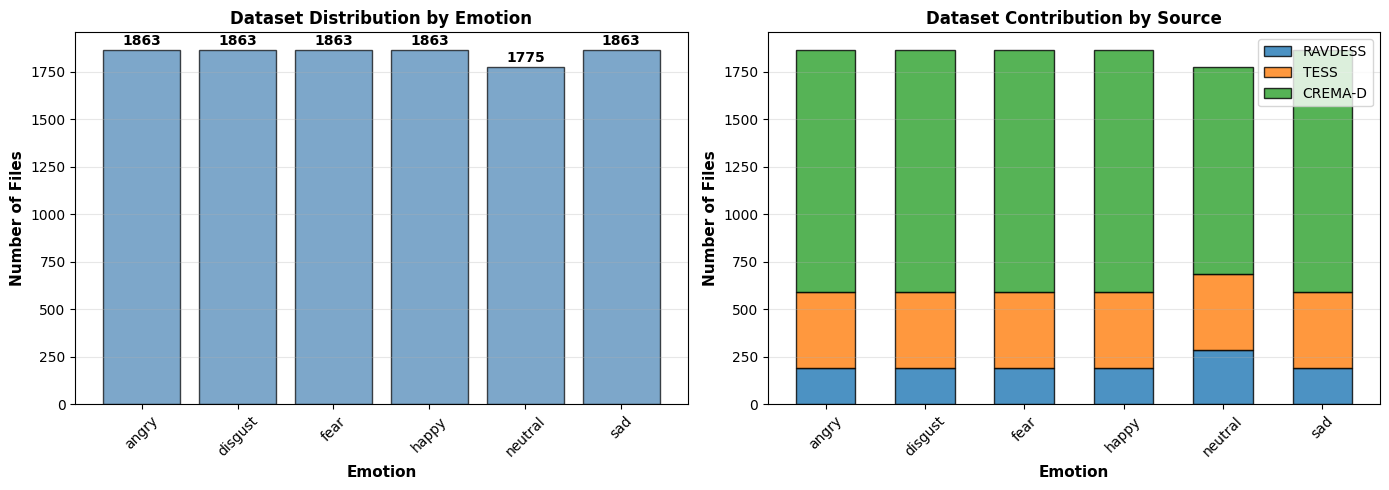

✓ Visualization saved to: dataset_distribution.png


In [11]:
# Visualize Dataset Distribution

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Distribution by Emotion (Total)
emotions = df_summary['Emotion'].tolist()
totals = df_summary['Total'].tolist()

axes[0].bar(emotions, totals, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Emotion', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Number of Files', fontsize=11, fontweight='bold')
axes[0].set_title('Dataset Distribution by Emotion', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Add value labels on bars
for i, v in enumerate(totals):
    axes[0].text(i, v + 10, str(v), ha='center', va='bottom', fontweight='bold')

# Plot 2: Stacked bar chart by dataset source
x = np.arange(len(emotions))
width = 0.6

ravdess_vals = df_summary['RAVDESS'].tolist()
tess_vals = df_summary['TESS'].tolist()
cremad_vals = df_summary['CREMA-D'].tolist()

axes[1].bar(x, ravdess_vals, width, label='RAVDESS', alpha=0.8, edgecolor='black')
axes[1].bar(x, tess_vals, width, bottom=ravdess_vals, label='TESS', alpha=0.8, edgecolor='black')
axes[1].bar(x, cremad_vals, width, bottom=np.array(ravdess_vals)+np.array(tess_vals), 
            label='CREMA-D', alpha=0.8, edgecolor='black')

axes[1].set_xlabel('Emotion', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Number of Files', fontsize=11, fontweight='bold')
axes[1].set_title('Dataset Contribution by Source', fontsize=12, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(emotions, rotation=45)
axes[1].legend(loc='upper right')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(combined_dir.parent / 'dataset_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Visualization saved to: dataset_distribution.png")